In [1]:
# Import necessary libraries
import os
import numpy as np
import matplotlib.pyplot as plt
from skimage.io import imread
from skimage.transform import resize
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D, concatenate
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.metrics import jaccard_score
import random

In [2]:
# Define the paths for the dataset
train_img_path = "/kaggle/input/bowl-2018-try-2/train folder/img"
train_mask_path = "/kaggle/input/bowl-2018-try-2/train folder/labelcol"
validation_img_path = "/kaggle/input/bowl-2018-try-2/validation folder/img"
validation_mask_path = "/kaggle/input/bowl-2018-try-2/validation folder/labelcol"
test_img_path = "/kaggle/input/bowl-2018-try-2/test folder/img"
test_mask_path = "/kaggle/input/bowl-2018-try-2/test folder/labelcol"

# Define image dimensions
IMG_HEIGHT, IMG_WIDTH = 128, 128  # Resized dimensions
IMG_CHANNELS = 3  # RGB


In [3]:
# Load and preprocess the images and masks
def load_data(img_path, mask_path, img_height, img_width):
    images = []
    masks = []
    for file_name in os.listdir(img_path):
        # Load and normalize image
        img = imread(os.path.join(img_path, file_name))
        img = resize(img, (img_height, img_width, IMG_CHANNELS), mode='constant', preserve_range=True)
        img = img / 255.0  # Normalize to [0, 1]
        images.append(img)

        # Load and normalize corresponding mask
        mask = imread(os.path.join(mask_path, file_name), as_gray=True)
        mask = resize(mask, (img_height, img_width, 1), mode='constant', preserve_range=True)
        mask = mask / 255.0  # Normalize to [0, 1]
        masks.append(mask)

    return np.array(images), np.array(masks)

# Load training data
train_images, train_masks = load_data(train_img_path, train_mask_path, IMG_HEIGHT, IMG_WIDTH)

# Load validation data
validation_images, validation_masks = load_data(validation_img_path, validation_mask_path, IMG_HEIGHT, IMG_WIDTH)

# Load test data
test_images, test_masks = load_data(test_img_path, test_mask_path, IMG_HEIGHT, IMG_WIDTH)

# Print shapes for confirmation
print("Train Images Shape:", train_images.shape)
print("Train Masks Shape:", train_masks.shape)
print("Validation Images Shape:", validation_images.shape)
print("Validation Masks Shape:", validation_masks.shape)
print("Test Images Shape:", test_images.shape)
print("Test Masks Shape:", test_masks.shape)


Train Images Shape: (520, 128, 128, 3)
Train Masks Shape: (520, 128, 128, 1)
Validation Images Shape: (75, 128, 128, 3)
Validation Masks Shape: (75, 128, 128, 1)
Test Images Shape: (76, 128, 128, 3)
Test Masks Shape: (76, 128, 128, 1)


In [4]:
# Define U-Net model
def unet_model(input_size=(128, 128, 3)):
    inputs = Input(input_size)
    
    # Encoder (downsampling)
    c1 = Conv2D(64, (3, 3), activation='relu', padding='same')(inputs)
    c1 = Conv2D(64, (3, 3), activation='relu', padding='same')(c1)
    p1 = MaxPooling2D((2, 2))(c1)
    
    c2 = Conv2D(128, (3, 3), activation='relu', padding='same')(p1)
    c2 = Conv2D(128, (3, 3), activation='relu', padding='same')(c2)
    p2 = MaxPooling2D((2, 2))(c2)
    
    c3 = Conv2D(256, (3, 3), activation='relu', padding='same')(p2)
    c3 = Conv2D(256, (3, 3), activation='relu', padding='same')(c3)
    p3 = MaxPooling2D((2, 2))(c3)
    
    # Bottleneck
    c4 = Conv2D(512, (3, 3), activation='relu', padding='same')(p3)
    c4 = Conv2D(512, (3, 3), activation='relu', padding='same')(c4)
    
    # Decoder (upsampling)
    u1 = UpSampling2D((2, 2))(c4)
    u1 = concatenate([u1, c3])
    c5 = Conv2D(256, (3, 3), activation='relu', padding='same')(u1)
    c5 = Conv2D(256, (3, 3), activation='relu', padding='same')(c5)
    
    u2 = UpSampling2D((2, 2))(c5)
    u2 = concatenate([u2, c2])
    c6 = Conv2D(128, (3, 3), activation='relu', padding='same')(u2)
    c6 = Conv2D(128, (3, 3), activation='relu', padding='same')(c6)
    
    u3 = UpSampling2D((2, 2))(c6)
    u3 = concatenate([u3, c1])
    c7 = Conv2D(64, (3, 3), activation='relu', padding='same')(u3)
    c7 = Conv2D(64, (3, 3), activation='relu', padding='same')(c7)
    
    # Output layer
    outputs = Conv2D(1, (1, 1), activation='sigmoid')(c7)
    
    model = Model(inputs=[inputs], outputs=[outputs])
    model.compile(optimizer=Adam(learning_rate=1e-4), loss='binary_crossentropy', metrics=['accuracy'])
    return model

# Build the model
model = unet_model()
model.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 128,  │      1,792 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 128, 128,  │     36,928 │ conv2d[0][0]      │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 64, 64,    │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 64, 64,    │     73,856 │ max_pooling2d[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 64, 64,    │    147,584 │ conv2d_2[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 32, 32,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 32, 32,    │    295,168 │ max_pooling2d_1[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 32, 32,    │    590,080 │ conv2d_4[0][0]    │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 16, 16,    │          0 │ conv2d_5[0][0]    │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 16, 16,    │  1,180,160 │ max_pooling2d_2[… │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 16, 16,    │  2,359,808 │ conv2d_6[0][0]    │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d       │ (None, 32, 32,    │          0 │ conv2d_7[0][0]    │
│ (UpSampling2D)      │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 32, 32,    │          0 │ up_sampling2d[0]… │
│ (Concatenate)       │ 768)              │            │ conv2d_5[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 32, 32,    │  1,769,728 │ concatenate[0][0] │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 32, 32,    │    590,080 │ conv2d_8[0][0]    │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_1     │ (None, 64, 64,    │          0 │ conv2d_9[0][0]  

 Total params: 7,782,913 (29.69 MB)

 Trainable params: 7,782,913 (29.69 MB)

 Non-trainable params: 0 (0.00 B)

In [5]:
# Train the model
history = model.fit(
    train_images, train_masks,
    validation_data=(validation_images, validation_masks),
    batch_size=16,
    epochs=30,
    verbose=1
)


Epoch 1/30


I0000 00:00:1733769718.547010    1777 service.cc:145] XLA service 0x7bed8c002100 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1733769718.547079    1777 service.cc:153]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1733769718.547086    1777 service.cc:153]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5


 1/33 ━━━━━━━━━━━━━━━━━━━━ 16:21 31s/step - accuracy: 0.0620 - loss: 0.6966

I0000 00:00:1733769745.355789    1777 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


33/33 ━━━━━━━━━━━━━━━━━━━━ 65s 1s/step - accuracy: 0.7111 - loss: 0.6466 - val_accuracy: 0.8324 - val_loss: 0.4585
Epoch 2/30
33/33 ━━━━━━━━━━━━━━━━━━━━ 6s 176ms/step - accuracy: 0.7980 - loss: 0.4361 - val_accuracy: 0.8324 - val_loss: 0.3372
Epoch 3/30
33/33 ━━━━━━━━━━━━━━━━━━━━ 6s 182ms/step - accuracy: 0.8043 - loss: 0.3563 - val_accuracy: 0.8324 - val_loss: 0.2464
Epoch 4/30
33/33 ━━━━━━━━━━━━━━━━━━━━ 6s 188ms/step - accuracy: 0.7899 - loss: 0.2956 - val_accuracy: 0.8324 - val_loss: 0.1930
Epoch 5/30
33/33 ━━━━━━━━━━━━━━━━━━━━ 6s 189ms/step - accuracy: 0.7974 - loss: 0.2296 - val_accuracy: 0.8410 - val_loss: 0.1631
Epoch 6/30
33/33 ━━━━━━━━━━━━━━━━━━━━ 6s 191ms/step - accuracy: 0.8258 - loss: 0.1780 - val_accuracy: 0.8589 - val_loss: 0.1299
Epoch 7/30
33/33 ━━━━━━━━━━━━━━━━━━━━ 6s 192ms/step - accuracy: 0.8243 - loss: 0.1412 - val_accuracy: 0.8584 - val_loss: 0.1132
Epoch 8/30
33/33 ━━━━━━━━━━━━━━━━━━━━ 6s 189ms/step - accuracy: 0.8313 - loss: 0.1337 - val_accuracy: 0.8584 - val_lo

3/3 ━━━━━━━━━━━━━━━━━━━━ 17s 305ms/step
Raw prediction range: 4.4660675e-10 0.999528


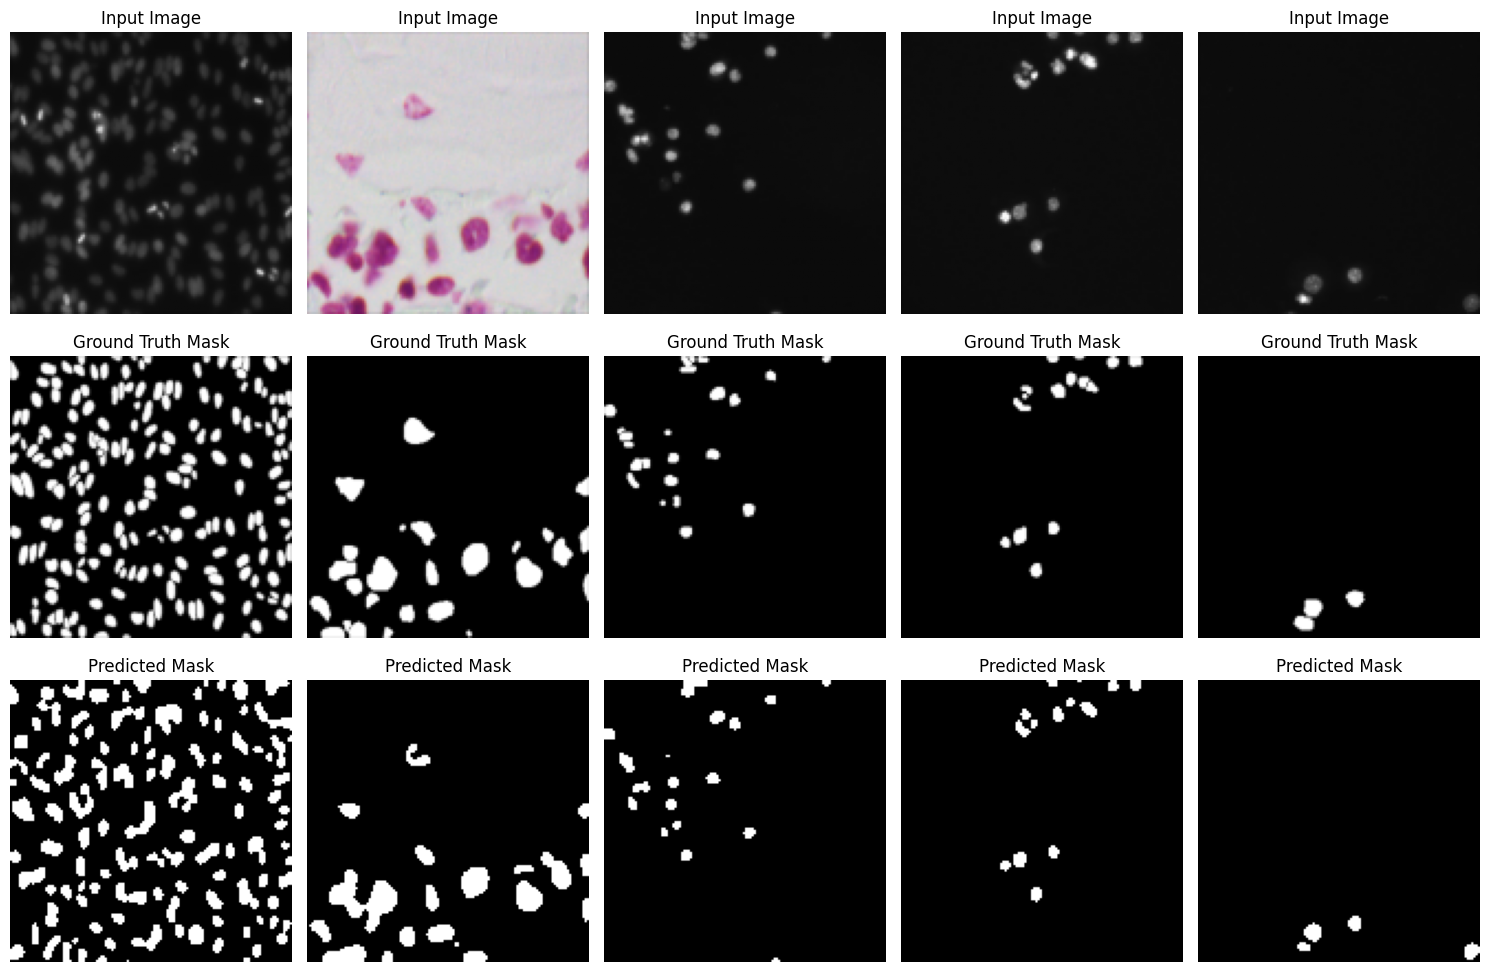

In [6]:
# Generate raw predictions
raw_preds = model.predict(validation_images)
print("Raw prediction range:", raw_preds.min(), raw_preds.max())

# Threshold predictions to binary masks
preds_binary = (raw_preds > 0.5).astype(np.uint8)

# Randomly select 5 samples
random_idx = random.sample(range(len(validation_images)), 5)

plt.figure(figsize=(15, 10))
for i, idx in enumerate(random_idx):
    # Input Image
    plt.subplot(3, 5, i + 1)
    plt.imshow(validation_images[idx])
    plt.title("Input Image")
    plt.axis('off')
    
    # Ground Truth Mask
    plt.subplot(3, 5, i + 6)
    plt.imshow(validation_masks[idx].squeeze(), cmap='gray')
    plt.title("Ground Truth Mask")
    plt.axis('off')
    
    # Predicted Mask
    plt.subplot(3, 5, i + 11)
    plt.imshow(preds_binary[idx].squeeze(), cmap='gray')
    plt.title("Predicted Mask")
    plt.axis('off')

plt.tight_layout()
plt.show()


In [7]:
# Ensure test_masks is binary
test_masks_binary = (test_masks > 0.5).astype(np.uint8)  # Threshold ground truth masks to binary

# Predict on test data
test_preds = model.predict(test_images)

# Threshold predictions to binary
test_preds_binary = (test_preds > 0.5).astype(np.uint8)

# Evaluate performance
def dice_coefficient(y_true, y_pred):
    smooth = 1.0  # Avoid division by zero
    y_true_f = y_true.flatten()
    y_pred_f = y_pred.flatten()
    intersection = np.sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (np.sum(y_true_f) + np.sum(y_pred_f) + smooth)

def evaluate_performance(y_true, y_pred):
    dice = dice_coefficient(y_true, y_pred)
    iou = jaccard_score(y_true.flatten(), y_pred.flatten(), average='binary')
    accuracy = np.mean(y_true == y_pred)
    return dice, iou, accuracy

# Evaluate on test set
dice, iou, accuracy = evaluate_performance(test_masks_binary, test_preds_binary)

print(f"Test Dice Coefficient: {dice:.4f}")
print(f"Test IoU (Jaccard Index): {iou:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

3/3 ━━━━━━━━━━━━━━━━━━━━ 10s 5s/step
Test Dice Coefficient: 0.8821
Test IoU (Jaccard Index): 0.7891
Test Accuracy: 0.9721


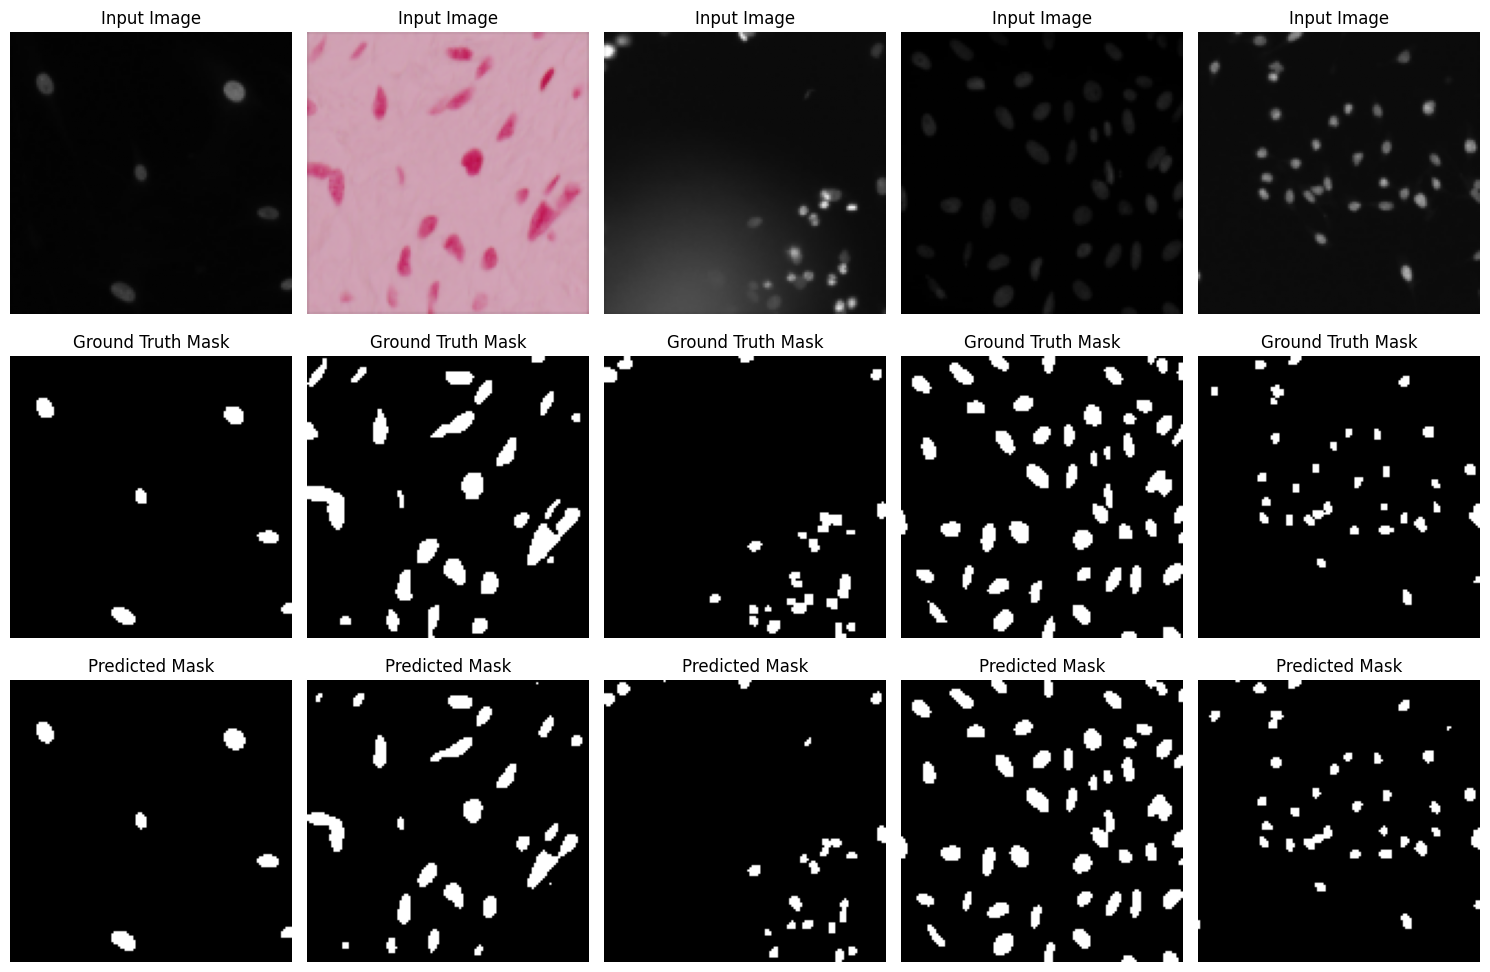

In [8]:
# Visualize a few test samples
random_idx = random.sample(range(len(test_images)), 5)

plt.figure(figsize=(15, 10))
for i, idx in enumerate(random_idx):
    # Input Image
    plt.subplot(3, 5, i + 1)
    plt.imshow(test_images[idx])
    plt.title("Input Image")
    plt.axis('off')
    
    # Ground Truth Mask
    plt.subplot(3, 5, i + 6)
    plt.imshow(test_masks_binary[idx].squeeze(), cmap='gray')
    plt.title("Ground Truth Mask")
    plt.axis('off')
    
    # Predicted Mask
    plt.subplot(3, 5, i + 11)
    plt.imshow(test_preds_binary[idx].squeeze(), cmap='gray')
    plt.title("Predicted Mask")
    plt.axis('off')

plt.tight_layout()
plt.show()


In [10]:
# Save the trained model
model.save("unet_model_try_2.h5")